# **Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# **Data Import & Exploration**

In [2]:
# Load dataset
df = pd.read_csv("household_power_consumption.csv",
                 sep=";",
                 parse_dates={"datetime": ["Date", "Time"]},
                 # Use errors='coerce' to handle any parsing errors by turning them into NaT
                 date_format="%d/%m/%Y %H:%M:%S", # Specify the date format
                 na_values="?",
                 low_memory=False
)

# Display first five rows
print("First 5 rows:")
display(df.head())

# Check data shape annd data types
print("\nDataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

First 5 rows:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00



Dataset Shape: (441934, 10)

Data Types:
Date                             object
Time                             object
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
datetime                 datetime64[ns]
dtype: object


# **Handling Missing Values**

In [3]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# Fill missing values with column mean (for numeric columns)
df = df.fillna(df.mean(numeric_only=True))

# Verify there are no more missing values
print("\nAfter Filling Missing Values:")
print(df.isnull().sum())

Missing Values per Column:
Global_active_power      3930
Global_reactive_power    3930
Voltage                  3930
Global_intensity         3930
Sub_metering_1           3930
Sub_metering_2           3931
Sub_metering_3           3931
datetime                    0
dtype: int64

After Filling Missing Values:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
datetime                 0
dtype: int64


# **Data Visualization**

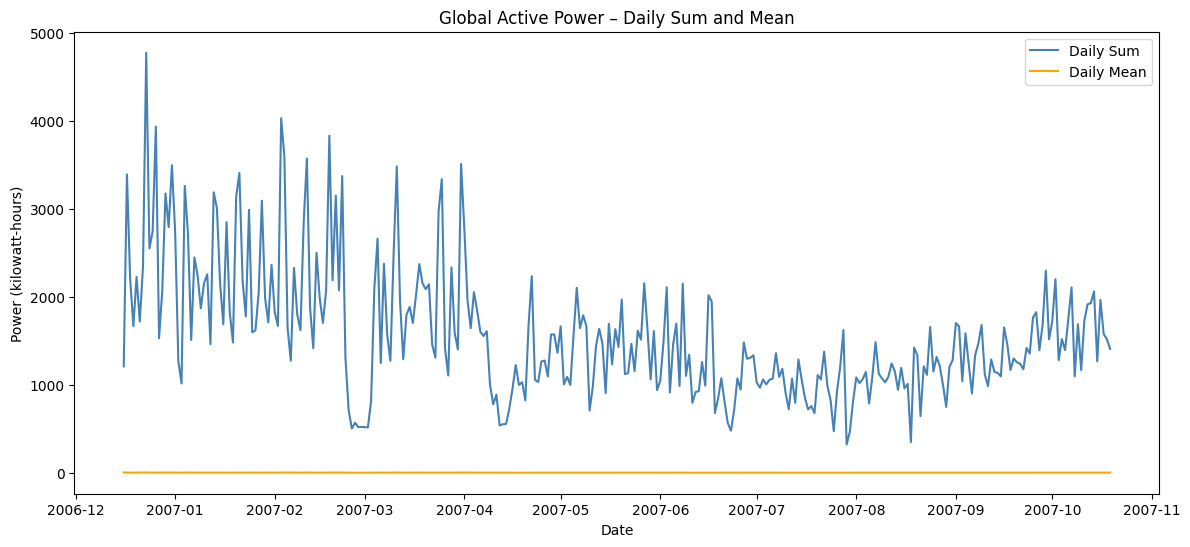

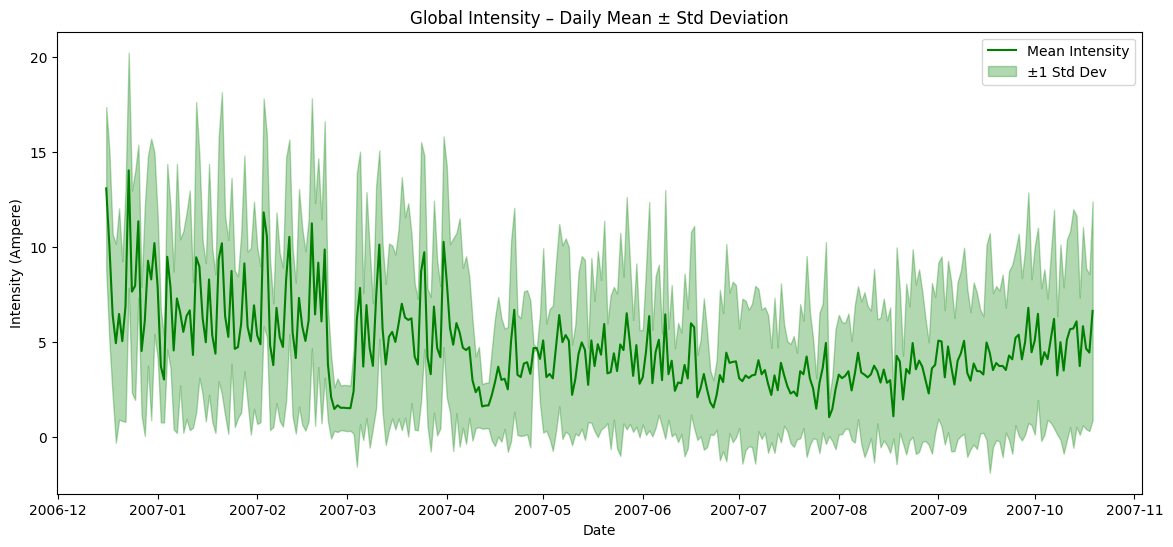

In [4]:
# Set the 'datetime' column as the index
df = df.set_index('datetime')

# Resample Global_active_power daily
daily_sum = df['Global_active_power'].resample('D').sum()
daily_mean = df['Global_active_power'].resample('D').mean()

# Plot both
plt.figure(figsize=(14,6))
plt.plot(daily_sum, label='Daily Sum', color='steelblue')
plt.plot(daily_mean, label='Daily Mean', color='orange')
plt.title('Global Active Power – Daily Sum and Mean')
plt.xlabel('Date')
plt.ylabel('Power (kilowatt-hours)')
plt.legend()
plt.show()

# Resample Global_intensity daily
daily_intensity = df['Global_intensity'].resample('D')

mean_intensity = daily_intensity.mean()
std_intensity = daily_intensity.std()

plt.figure(figsize=(14,6))
plt.plot(mean_intensity, label='Mean Intensity', color='green')
plt.fill_between(mean_intensity.index,
                 mean_intensity - std_intensity,
                 mean_intensity + std_intensity,
                 color='green', alpha=0.3, label='±1 Std Dev')
plt.title('Global Intensity – Daily Mean ± Std Deviation')
plt.xlabel('Date')
plt.ylabel('Intensity (Ampere)')
plt.legend()
plt.show()

# **Data Preprocessing for LSTM**

In [5]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# Initialize and fit the scaler
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(numeric_df)

# Convert back to DataFrame (preserving column names and index)
scaled_df = pd.DataFrame(scaled_values, columns=numeric_df.columns, index=numeric_df.index)

print("Scaled data preview:")
scaled_df.head()

Scaled data preview:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,0.390442,0.364111,0.402340,0.391304,0.0,0.012821,0.85
2006-12-16 17:25:00,0.498489,0.379791,0.359447,0.491304,0.0,0.012821,0.80
2006-12-16 17:26:00,0.499811,0.433798,0.347395,0.491304,0.0,0.025641,0.85
2006-12-16 17:27:00,0.501133,0.437282,0.363346,0.491304,0.0,0.012821,0.85
2006-12-16 17:28:00,0.338496,0.459930,0.432116,0.334783,0.0,0.012821,0.85


In [6]:
# Use 80% for training, 20% for testing
split = int(len(scaled_df) * 0.8)
train, test = scaled_df[:split], scaled_df[split:]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

Training set shape: (353547, 7)
Testing set shape: (88387, 7)


In [7]:
def create_sequences(data, target_col, n_steps=60):
  X, y = [], []
  for i in range(len(data) - n_steps):
    X.append(data.iloc[i:i+n_steps].values)
    y.append(data.iloc[i + n_steps][target_col])
  return np.array(X), np.array(y)

n_steps = 60 # window size
target_col = "Global_active_power"

X_train, y_train = create_sequences(train, target_col, n_steps)
X_test,  y_test  = create_sequences(test,  target_col, n_steps)

print("Training shape:", X_train.shape, y_train.shape)
print("Testing shape:", X_test.shape, y_test.shape)

Training shape: (353487, 60, 7) (353487,)
Testing shape: (88327, 60, 7) (88327,)


# **Building an LSTM Model**

In [8]:
# Shaping the model needs
n_timestamps = X_train.shape[1]
n_features = X_train.shape[2]
print("Input shapes for LSTM:", (n_timestamps, n_features))

# Building the LSTM model (regression)
model = models.Sequential([
    layers.Input(shape=(n_timestamps, n_features)),   # e.g., (60, 7) — both ints
    layers.LSTM(64, return_sequences=True, dropout=0.2),  # 64 is an int; dropout is a separate float kwarg
    layers.LSTM(32, dropout=0.2),
    layers.Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

# Compile - we predict a continous value so we use MSE for loss and L1/MAE as a metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

#Helpful Callbacks
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks .ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Training
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=62,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Input shapes for LSTM: (60, 7)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 0.0025 - mae: 0.0275 - val_loss: 4.3512e-04 - val_mae: 0.0091 - learning_rate: 0.0010
Epoch 2/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 0.0012 - mae: 0.0176 - val_loss: 9.1228e-04 - val_mae: 0.0225 - learning_rate: 0.0010
Epoch 3/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 0.0012 - mae: 0.0167 - val_loss: 6.2974e-04 - val_mae: 0.0149 - learning_rate: 0.0010
Epoch 4/10
5130/5132 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - mae: 0.0160
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 0.0011 - mae: 0.0160 - val_loss: 7.3780e-04 - val_mae: 0.0156 - learning_rate: 0.0010
Epoch 5/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 0.0011 - mae: 0.0155 - val_loss: 6.5048e-04 - val_mae: 0.0130 - learning_rate: 5.0000e-04
Epoch 6/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 0.0011 - mae: 0.0153 - val_loss: 6.1813e

# **Training and Evaluating the LSTM Model**

Epoch 1/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 0.0015 - mae: 0.0179 - val_loss: 6.4335e-04 - val_mae: 0.0131 - learning_rate: 3.9063e-06
Epoch 2/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 0.0015 - mae: 0.0178 - val_loss: 6.4417e-04 - val_mae: 0.0131 - learning_rate: 3.9063e-06
Epoch 3/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 0.0015 - mae: 0.0178 - val_loss: 6.4369e-04 - val_mae: 0.0131 - learning_rate: 3.9063e-06
Epoch 4/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 0.0015 - mae: 0.0179 - val_loss: 6.4939e-04 - val_mae: 0.0132 - learning_rate: 3.9063e-06
Epoch 5/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 0.0015 - mae: 0.0178 - val_loss: 6.4036e-04 - val_mae: 0.0132 - learning_rate: 1.9531e-06
Epoch 6/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 0.0015 - mae: 0.0177 - val_loss: 6.4064e-04 - val_mae: 0.0132 - learning_rate: 1.9531e-06
Epoch 7/10
5132/5132 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 0.0015 - mae: 0.017

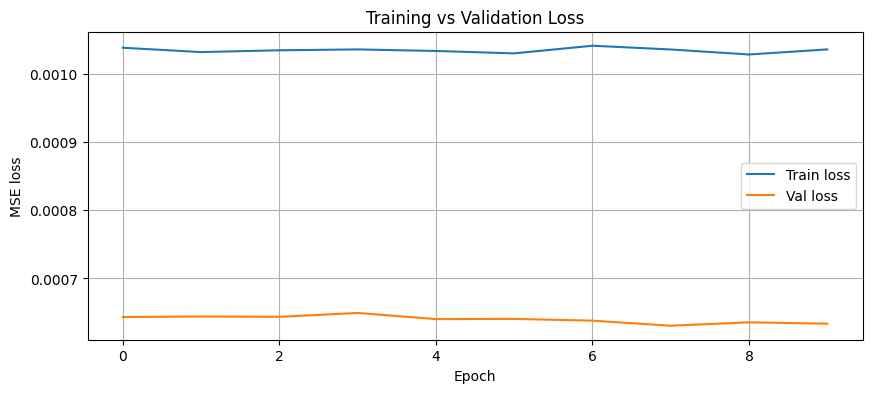

Test MSE: 0.001303
Test MAE: 0.0202
2761/2761 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step


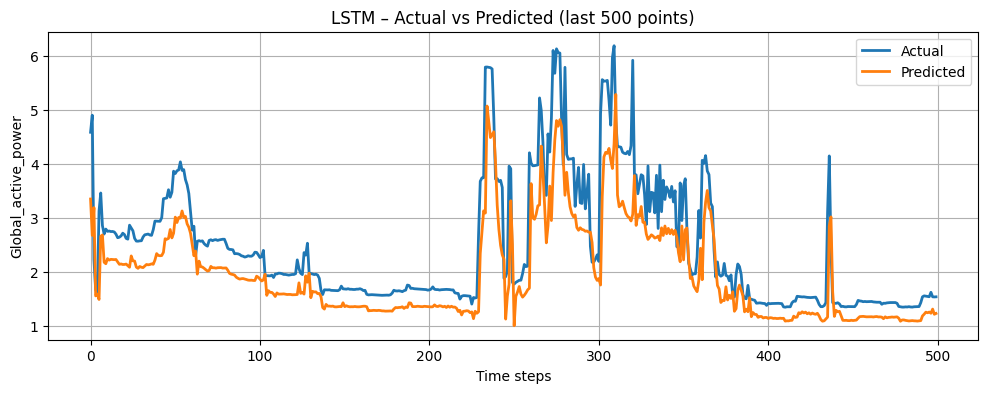

RMSE: 0.3822
MAE : 0.2142


In [14]:
# Train
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    epochs=10,                # bump up/down as you like
    batch_size=62,            # common for time series
    validation_split=0.1,     # use 10% of training as validation
    shuffle=False,            # important for sequence data
    callbacks=[es, rlr],
    verbose=1
)

# Learning curves
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True)
plt.show()

# Evaluate on test set
test_results = model.evaluate(X_test, y_test, verbose=0)
test_loss = test_results[0]
test_mae = test_results[1] # Assuming 'mae' is the second metric

print(f"Test MSE: {test_loss:.6f}")
print(f"Test MAE: {test_mae:.4f}") # Print MAE as well


# Predict
y_pred_scaled = model.predict(X_test)

# Inverse transform the scaled predictions and true values using the correct scaler
# We need to create dummy columns to inverse transform correctly since the scaler was fit on multiple features
dummy_pred = np.zeros((y_pred_scaled.shape[0], scaled_df.shape[1]))
dummy_pred[:, 0] = y_pred_scaled[:, 0]
y_pred = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_test = np.zeros((y_test.shape[0], scaled_df.shape[1]))
dummy_test[:, 0] = y_test
y_true = scaler.inverse_transform(dummy_test)[:, 0]


# Plot: predictions vs actual on a recent window
plt.figure(figsize=(12,4))
plt.plot(y_true[-500:], label="Actual", linewidth=2)
plt.plot(y_pred[-500:], label="Predicted", linewidth=2)
plt.title("LSTM – Actual vs Predicted (last 500 points)")
plt.xlabel("Time steps")
plt.ylabel("Global_active_power")
plt.legend()
plt.grid(True)
plt.show()

# Simple error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_true, y_pred) # Calculate MSE
rmse = np.sqrt(mse) # Calculate RMSE
mae  = mean_absolute_error(y_true, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")